Task 06 — Music Genre Classification

Problem Statement: Build a machine learning model that classifies music tracks into different genres using audio features extracted from the GTZAN dataset, and evaluate the performance of the model using multi-class classification techniques.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("features_30_sec.csv")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (1000, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nGenre counts:\n", df["label"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   str    
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             1000 non-nu

In [4]:
# Drop filename if it exists
if "filename" in df.columns:
    df = df.drop(columns=["filename"])

X = df.drop(columns=["label"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 58)
y shape: (1000,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (800, 58) Test: (200, 58)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("LogReg Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

LogReg Accuracy: 0.74
              precision    recall  f1-score   support

       blues       0.68      0.75      0.71        20
   classical       0.95      0.95      0.95        20
     country       0.70      0.70      0.70        20
       disco       0.85      0.55      0.67        20
      hiphop       0.76      0.65      0.70        20
        jazz       0.71      0.85      0.77        20
       metal       0.94      0.75      0.83        20
         pop       0.81      0.85      0.83        20
      reggae       0.62      0.80      0.70        20
        rock       0.52      0.55      0.54        20

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



In [8]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=10, gamma="scale")
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.765
              precision    recall  f1-score   support

       blues       0.77      0.85      0.81        20
   classical       0.74      0.85      0.79        20
     country       0.85      0.85      0.85        20
       disco       0.65      0.55      0.59        20
      hiphop       0.89      0.80      0.84        20
        jazz       0.77      0.85      0.81        20
       metal       0.94      0.80      0.86        20
         pop       0.70      0.70      0.70        20
      reggae       0.65      0.75      0.70        20
        rock       0.72      0.65      0.68        20

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RandomForest Accuracy: 0.8
              precision    recall  f1-score   support

       blues       0.89      0.80      0.84        20
   classical       0.83      0.95      0.88        20
     country       0.77      0.85      0.81        20
       disco       0.76      0.65      0.70        20
      hiphop       0.73      0.80      0.76        20
        jazz       0.76      0.80      0.78        20
       metal       0.89      0.85      0.87        20
         pop       0.86      0.90      0.88        20
      reggae       0.73      0.80      0.76        20
        rock       0.80      0.60      0.69        20

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



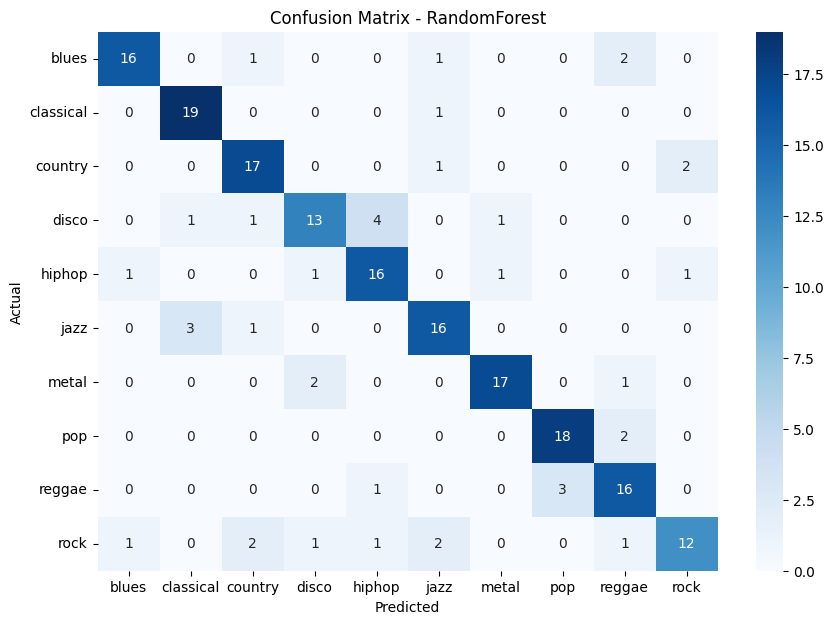

In [10]:
cm = confusion_matrix(y_test, y_pred_rf, labels=sorted(y.unique()))

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RandomForest")
plt.show()

In [11]:
results_tabular = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM (RBF)", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
    ]
}).sort_values("Accuracy", ascending=False)

results_tabular

,Model,Accuracy
2,Random Forest,0.800
1,SVM (RBF),0.765
0,Logistic Regression,0.740


In [12]:
!pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import tensorflow as tf

IMG_DIR = "images_original"

IMG_SIZE = (224, 224)
BATCH = 32
SEED = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    IMG_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    IMG_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 999 files belonging to 10 classes.
Using 800 files for training.
Found 999 files belonging to 10 classes.
Using 199 files for validation.
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [14]:
from tensorflow.keras import layers, models

cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = cnn.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


C:\Users\shahd\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 493ms/step - accuracy: 0.1412 - loss: 2.4858 - val_accuracy: 0.2010 - val_loss: 2.2178
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 443ms/step - accuracy: 0.2600 - loss: 2.0490 - val_accuracy: 0.3467 - val_loss: 1.8569
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 436ms/step - accuracy: 0.3713 - loss: 1.7929 - val_accuracy: 0.3819 - val_loss: 1.6887
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 437ms/step - accuracy: 0.4563 - loss: 1.5493 - val_accuracy: 0.4372 - val_loss: 1.4572
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 438ms/step - accuracy: 0.5275 - loss: 1.3432 - val_accuracy: 0.5327 - val_loss: 1.4172
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 469ms/step - accuracy: 0.6000 - loss: 1.1806 - val_accuracy: 0.5477 - val_loss: 1.3015
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 473ms/step - accuracy: 0.6700 - loss: 0.9544 - val_accuracy: 0.5729 - val_loss: 1.2709
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 463ms/step - accuracy: 0.7212 - loss: 0.7909 - val_accuracy: 0.623

In [15]:
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

transfer_model = tf.keras.Sequential([
    layers.Rescaling(1./255),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tl = transfer_model.fit(train_ds, validation_data=val_ds, epochs=8)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 630ms/step - accuracy: 0.1787 - loss: 2.3505 - val_accuracy: 0.3266 - val_loss: 1.9207
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 551ms/step - accuracy: 0.3587 - loss: 1.7996 - val_accuracy: 0.4271 - val_loss: 1.6481
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 591ms/step - accuracy: 0.4500 - loss: 1.6104 - val_accuracy: 0.5477 - val_loss: 1.4430
Epoch 4/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.4950 - loss: 1.4546 - val_accuracy: 0.5729 - val_loss: 1.3865
Epoch 5/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 515ms/step - accuracy: 0.5263 - loss: 1.3701 - val_accuracy: 0.5427 - val_loss: 1.3277
Epoch 6/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 516ms/step - accuracy: 0.5425 - loss: 1.2970 - val_accuracy: 0.5779 - val_loss: 1.2715
Epoch 7/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 574ms/step - accuracy: 0.5763 - loss: 1.2355 - val_accuracy: 0.5779 - val_loss: 1.2826
Epoch 8/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 574ms/step - a

In [16]:
base.trainable = True

# fine-tune only last layers
for layer in base.layers[:-40]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = transfer_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 798ms/step - accuracy: 0.2512 - loss: 3.3235 - val_accuracy: 0.6030 - val_loss: 1.2276
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 682ms/step - accuracy: 0.3388 - loss: 2.6204 - val_accuracy: 0.6030 - val_loss: 1.2453
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 694ms/step - accuracy: 0.4187 - loss: 2.1368 - val_accuracy: 0.5980 - val_loss: 1.2889
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 682ms/step - accuracy: 0.4512 - loss: 1.7608 - val_accuracy: 0.5729 - val_loss: 1.3539
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 815ms/step - accuracy: 0.5050 - loss: 1.4712 - val_accuracy: 0.5327 - val_loss: 1.4197


In [17]:
final_compare = pd.DataFrame({
    "Approach": ["Tabular (Best)", "CNN", "Transfer Learning"],
    "Accuracy": [
        results_tabular["Accuracy"].max(),
        max(history.history["val_accuracy"]),
        max(history_tl.history["val_accuracy"])
    ]
})

final_compare

,Approach,Accuracy
0,Tabular (Best),0.800000
1,CNN,0.633166
2,Transfer Learning,0.592965


The tabular feature-based approach achieved the highest accuracy of 80%, outperforming both the CNN (63%) and transfer learning model (59%). This suggests that engineered audio features such as MFCCs and spectral statistics are highly effective for genre classification in the GTZAN dataset. Deep learning models on spectrogram images require larger datasets and longer training to surpass traditional machine learning approaches.